# 02 — Image Metrics Analysis

Phân tích chất lượng ảnh topology từ các iteration của thuật toán SIMP.

**Nguồn dữ liệu:** `data/Shape_Initial_shear/` và `data/Shape_Initial_stiff/` — ảnh PNG `iteration_*.png`.

**Chỉ số phân tích:**
- **Binary rate**: tỉ lệ pixel đen/trắng thuần (0 hoặc 1) so với tổng pixel
- **Edge density**: mật độ cạnh (dùng Sobel filter)
- **Noise ratio**: tỉ lệ pixel xám không thuộc 0 hoặc 1
- **Symmetry (L/R)**: độ đối xứng trái-phải

**Output figures:** `outputs/figures/image_metrics_*.png`

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from scipy.ndimage import sobel

# ── config ──
DATA_ROOT = Path('../data')
OUTPUT_DIR = Path('../outputs/figures')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
print('Setup OK')

Setup OK


## 1. Hàm tính metrics

In [10]:
def compute_image_metrics(img: np.ndarray):
    """
    Tính các chỉ số từ ảnh grayscale (giá trị 0..1).
    
    Returns:
        dict: binary_rate, edge_density, noise_ratio, sym_lr
    """
    h, w = img.shape
    total_pixels = h * w
    
    # Binary rate: pixel ≈ 0 hoặc ≈ 1
    black = (img < 0.05).sum()
    white = (img > 0.95).sum()
    binary_rate = (black + white) / total_pixels
    
    # Noise ratio: pixel xám
    gray = ((img >= 0.05) & (img <= 0.95)).sum()
    noise_ratio = gray / total_pixels
    
    # Edge density: Sobel gradient magnitude
    sx = sobel(img, axis=1)
    sy = sobel(img, axis=0)
    edges = np.hypot(sx, sy)
    edge_density = (edges > 0.15).sum() / total_pixels
    
    # Symmetry (left-right): tương quan pixel giữa nửa trái và nửa phải
    mid = w // 2
    left = img[:, :mid]
    right = img[:, -mid:]
    # Correlation coefficient giữa left và right (right flipped)
    left_flat = left.ravel()
    right_flat = np.fliplr(right).ravel()
    if left_flat.std() == 0 or right_flat.std() == 0:
        sym_lr = 0.0
    else:
        sym_lr = float(np.corrcoef(left_flat, right_flat)[0, 1])
    
    return {
        'binary_rate': binary_rate,
        'edge_density': edge_density,
        'noise_ratio': noise_ratio,
        'sym_lr': sym_lr,
    }

print('compute_image_metrics defined')

compute_image_metrics defined


## 2. Quét ảnh và tính metrics

In [11]:
def scan_images(base_dir, label):
    """Duyệt tất cả ảnh PNG trong các thư mục seed, tính metrics."""
    records = []
    for seed_dir in sorted(base_dir.iterdir()):
        if not seed_dir.is_dir():
            continue
        # Tìm các ảnh iteration
        png_files = sorted(seed_dir.glob('iteration_*.png'))
        if not png_files:
            continue
        for fpath in png_files:
            # Trích iteration number từ filename: iteration_00005.png -> 5
            iter_num = int(fpath.stem.split('_')[1])
            img = np.array(Image.open(fpath).convert('L')) / 255.0
            metrics = compute_image_metrics(img)
            records.append({
                'seed': seed_dir.name,
                'condition': label,
                'iteration': iter_num,
                **metrics,
            })
    return records

records_shear = scan_images(DATA_ROOT / 'Shape_Initial_shear', 'shear')
records_stiff = scan_images(DATA_ROOT / 'Shape_Initial_stiff', 'stiff')
all_records = records_shear + records_stiff

print(f'shear: {len(records_shear)} images, {len(set(r["seed"] for r in records_shear))} seeds')
print(f'stiff: {len(records_stiff)} images, {len(set(r["seed"] for r in records_stiff))} seeds')
print(f'total: {len(all_records)} images')

# Show sample
if all_records:
    sample = all_records[0]
    print(f'\nSample record:')
    for k, v in sample.items():
        print(f'  {k}: {v}')

shear: 541 images, 10 seeds
stiff: 444 images, 11 seeds
total: 985 images

Sample record:
  seed: Cross_regtangular_shear
  condition: shear
  iteration: 0
  binary_rate: 0.500418118466899
  edge_density: 0.016630662020905924
  noise_ratio: 0.49958188153310107
  sym_lr: 0.87703734529683


## 3. Binary rate over iterations

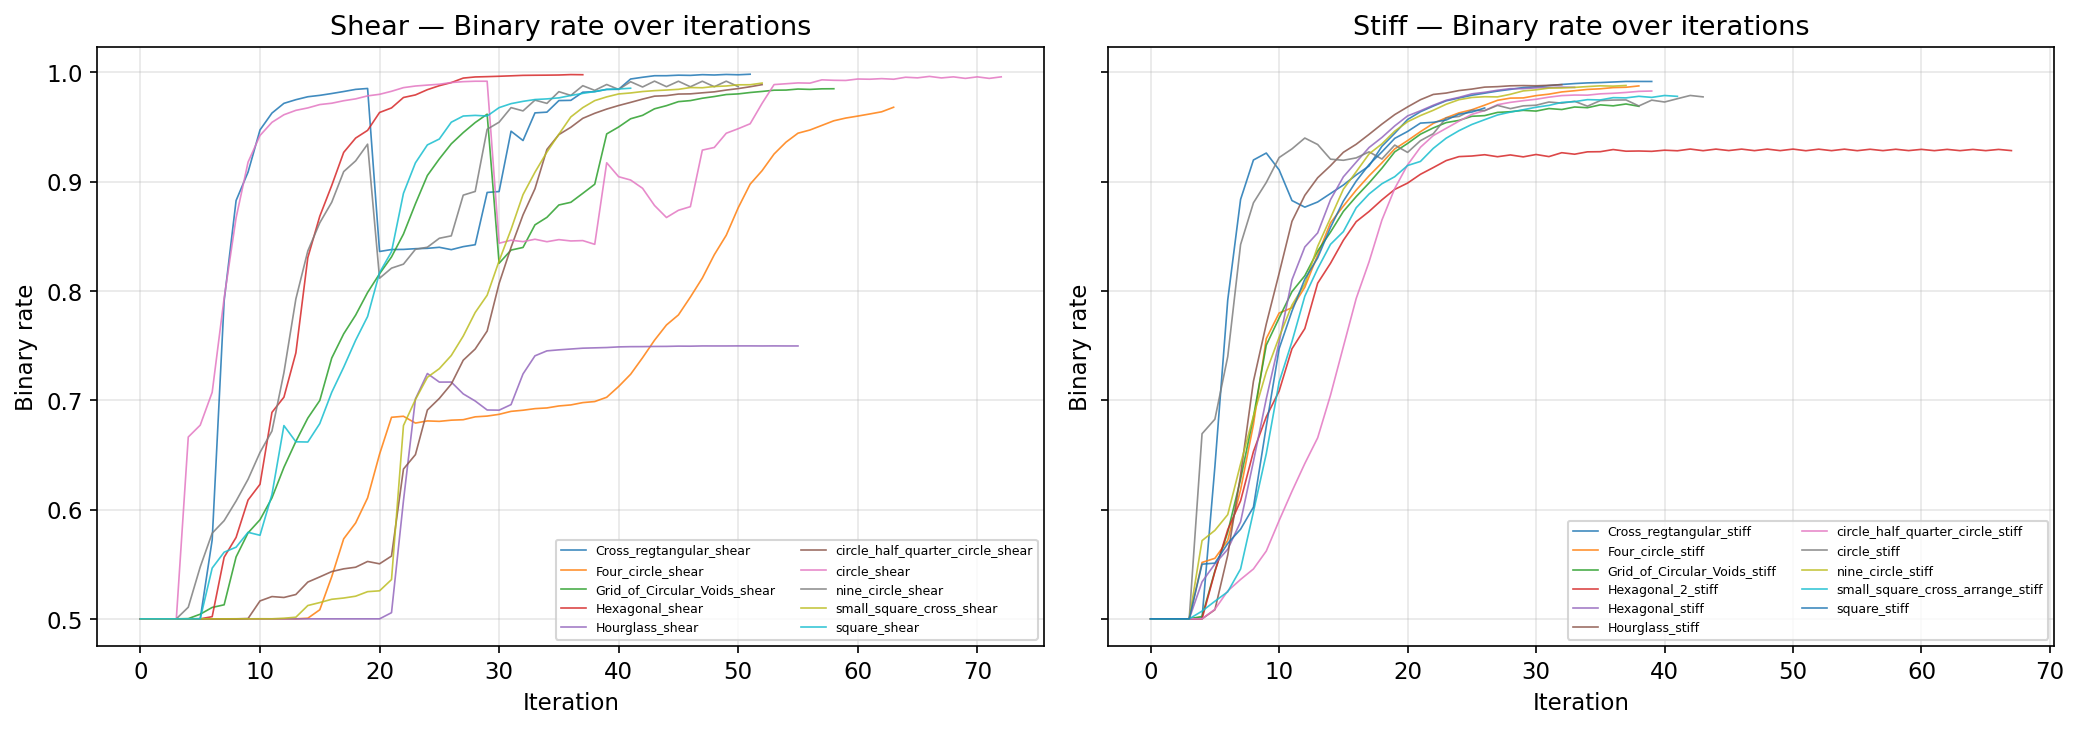

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (cond, label) in enumerate([('shear', 'Shear'), ('stiff', 'Stiff')]):
    ax = axes[idx]
    sub = [r for r in all_records if r['condition'] == cond]
    seeds_in = set(r['seed'] for r in sub)
    for seed in sorted(seeds_in):
        vals = [(r['iteration'], r['binary_rate']) for r in sub if r['seed'] == seed]
        vals.sort(key=lambda x: x[0])
        ax.plot([v[0] for v in vals], [v[1] for v in vals], label=seed, linewidth=0.8, alpha=0.85)
    ax.set_title(f'{label} — Binary rate over iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Binary rate')
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'image_metrics_binary_rate.png')
plt.show()

## 4. Edge density over iterations

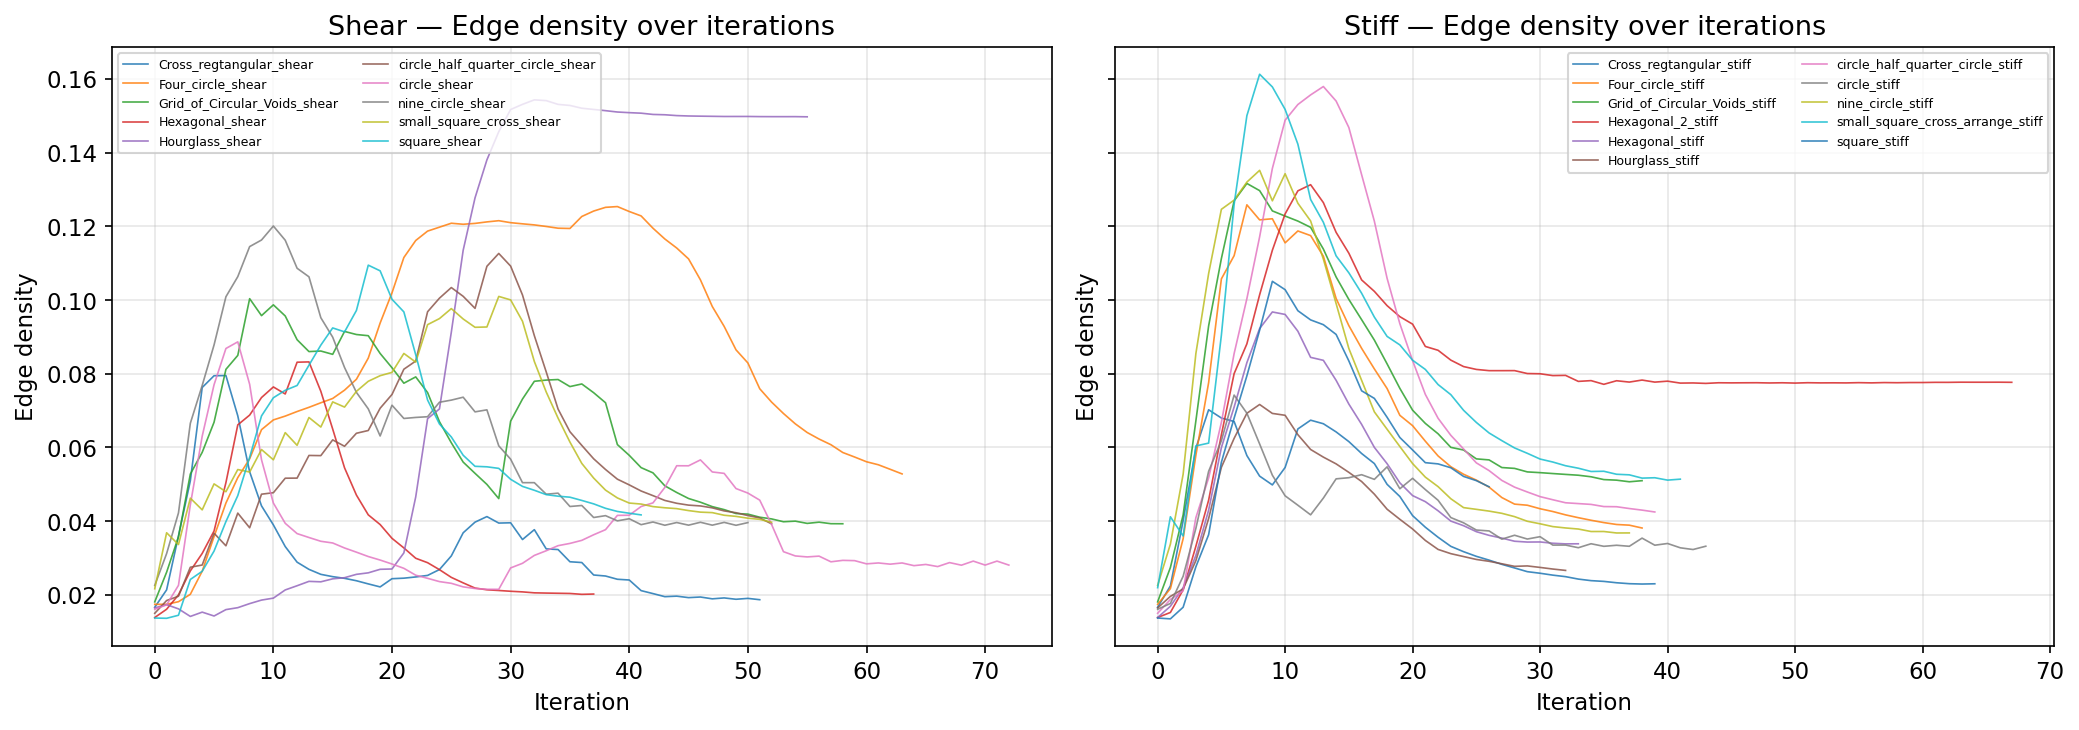

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (cond, label) in enumerate([('shear', 'Shear'), ('stiff', 'Stiff')]):
    ax = axes[idx]
    sub = [r for r in all_records if r['condition'] == cond]
    seeds_in = set(r['seed'] for r in sub)
    for seed in sorted(seeds_in):
        vals = [(r['iteration'], r['edge_density']) for r in sub if r['seed'] == seed]
        vals.sort(key=lambda x: x[0])
        ax.plot([v[0] for v in vals], [v[1] for v in vals], label=seed, linewidth=0.8, alpha=0.85)
    ax.set_title(f'{label} — Edge density over iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Edge density')
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'image_metrics_edge_density.png')
plt.show()

## 5. Noise ratio over iterations

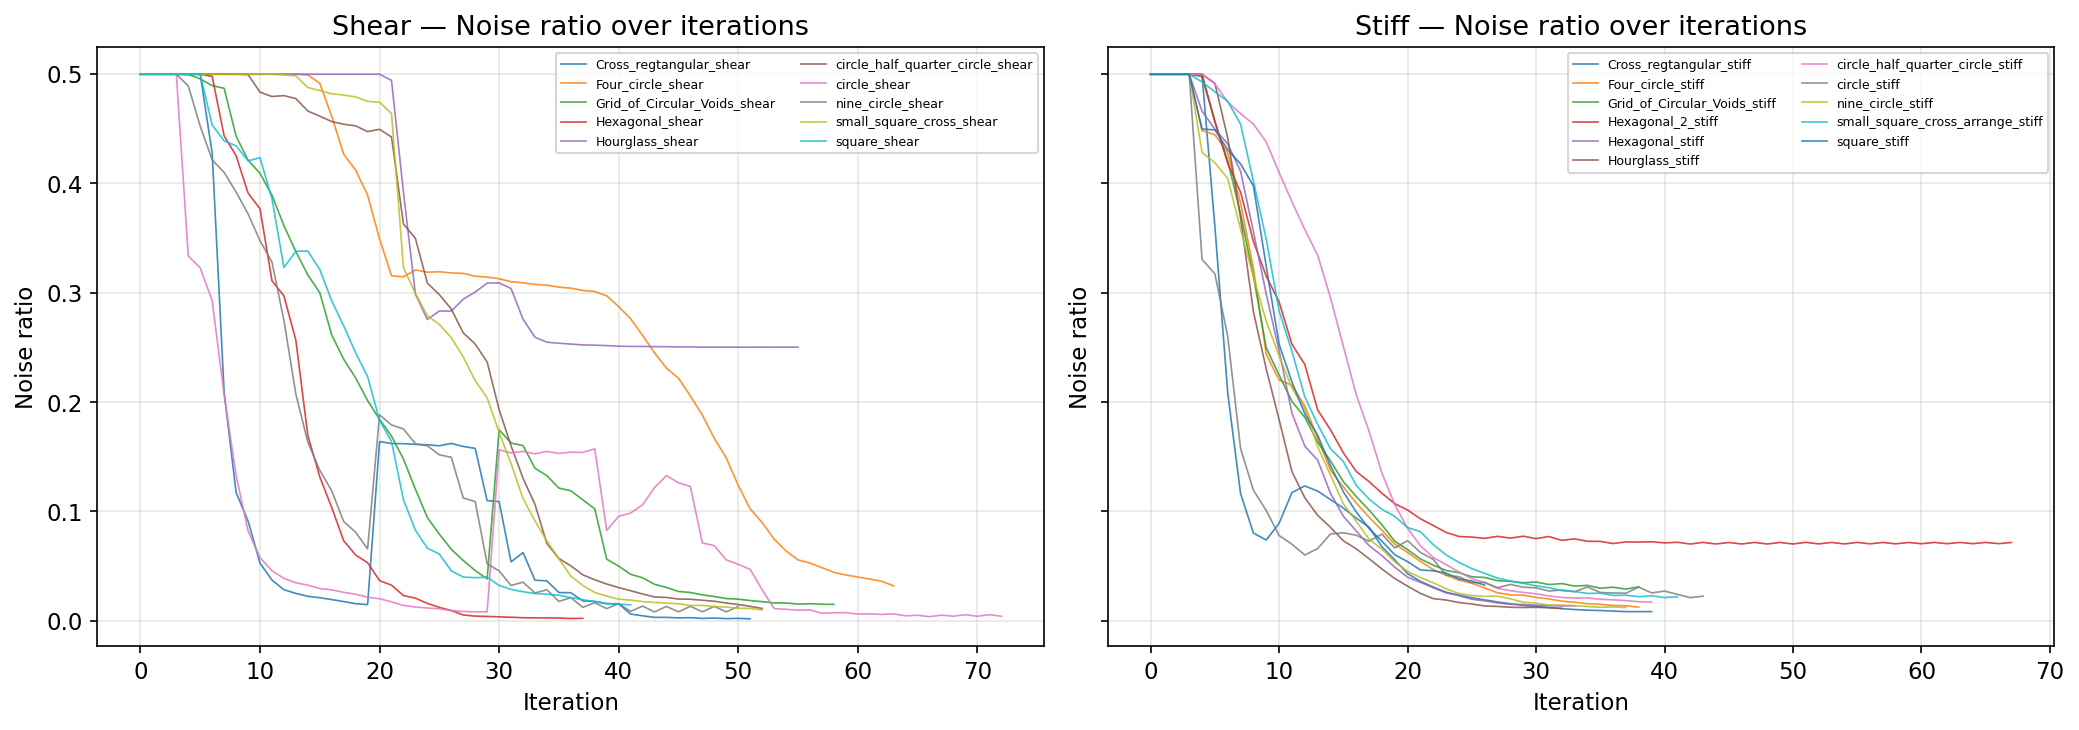

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (cond, label) in enumerate([('shear', 'Shear'), ('stiff', 'Stiff')]):
    ax = axes[idx]
    sub = [r for r in all_records if r['condition'] == cond]
    seeds_in = set(r['seed'] for r in sub)
    for seed in sorted(seeds_in):
        vals = [(r['iteration'], r['noise_ratio']) for r in sub if r['seed'] == seed]
        vals.sort(key=lambda x: x[0])
        ax.plot([v[0] for v in vals], [v[1] for v in vals], label=seed, linewidth=0.8, alpha=0.85)
    ax.set_title(f'{label} — Noise ratio over iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Noise ratio')
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'image_metrics_noise_ratio.png')
plt.show()

## 6. Symmetry (L/R) over iterations

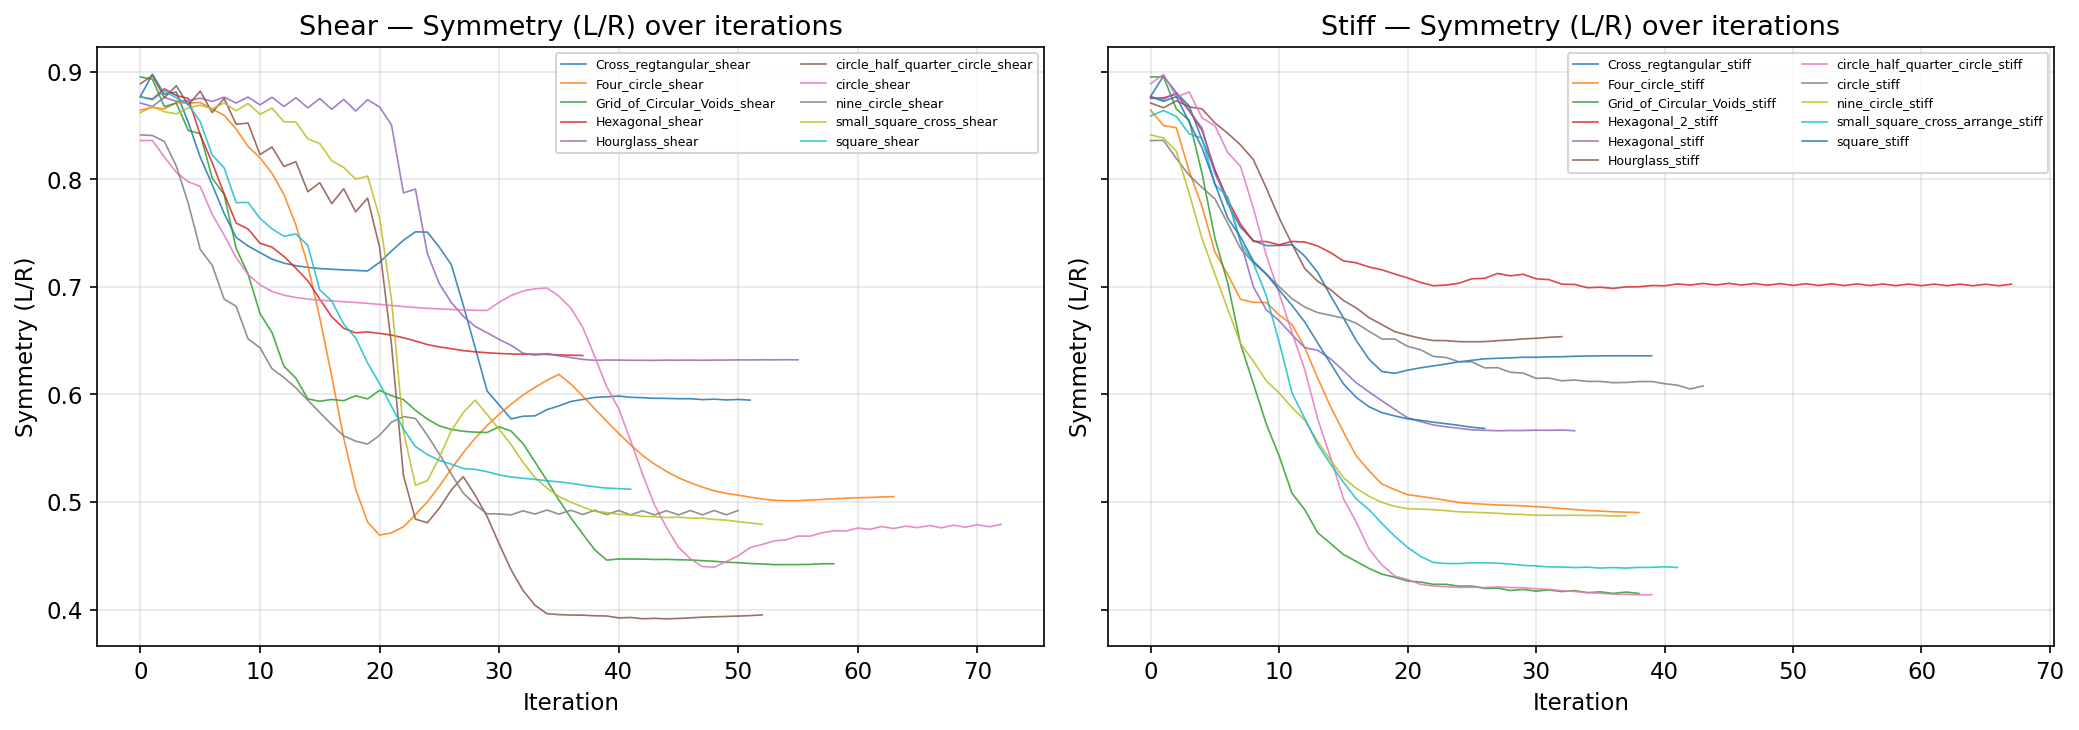

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (cond, label) in enumerate([('shear', 'Shear'), ('stiff', 'Stiff')]):
    ax = axes[idx]
    sub = [r for r in all_records if r['condition'] == cond]
    seeds_in = set(r['seed'] for r in sub)
    for seed in sorted(seeds_in):
        vals = [(r['iteration'], r['sym_lr']) for r in sub if r['seed'] == seed]
        vals.sort(key=lambda x: x[0])
        ax.plot([v[0] for v in vals], [v[1] for v in vals], label=seed, linewidth=0.8, alpha=0.85)
    ax.set_title(f'{label} — Symmetry (L/R) over iterations')
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Symmetry (L/R)')
    ax.legend(fontsize=6, ncol=2)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'image_metrics_sym_lr.png')
plt.show()

## 7. So sánh final iteration metrics giữa shear và stiff

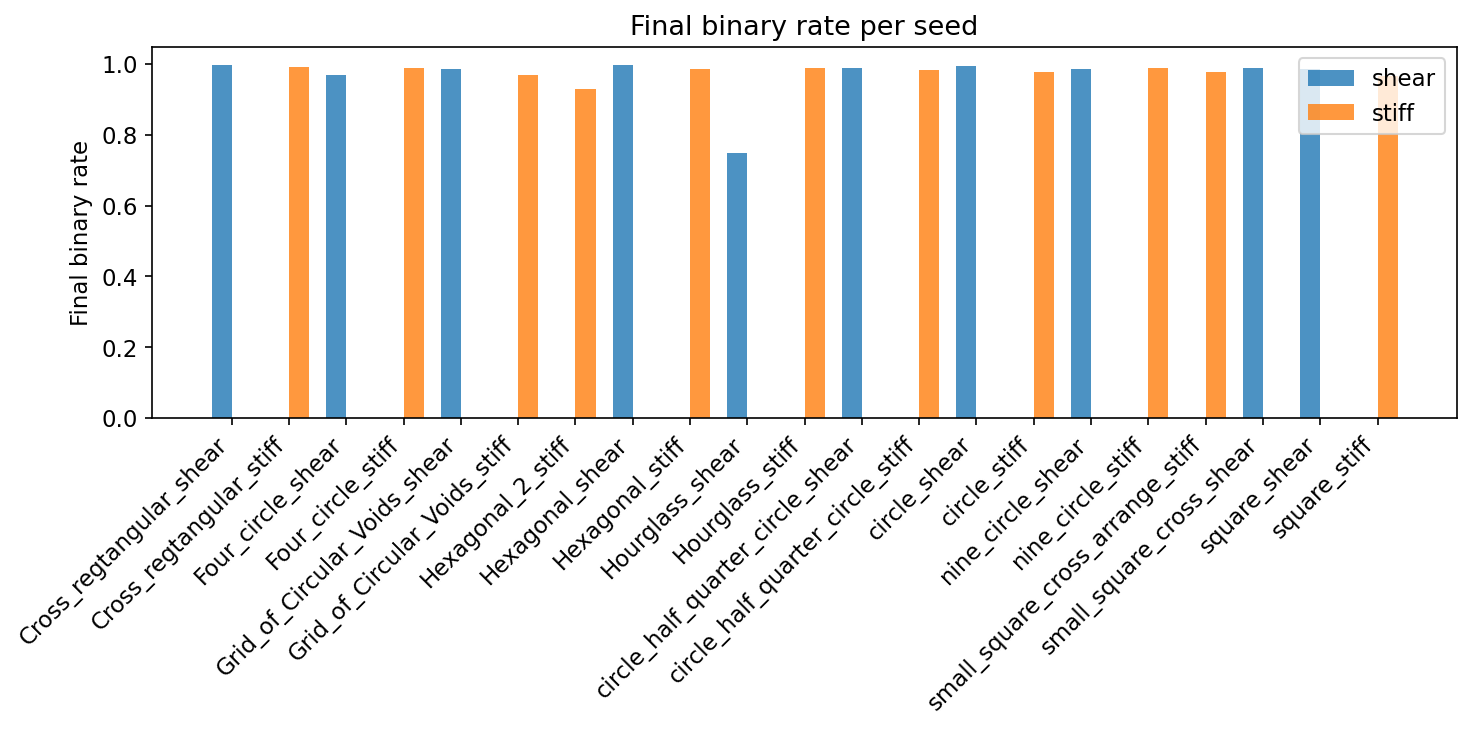

Done — all image metric figures saved to ../outputs/figures


In [16]:
# Lấy metrics của iteration cuối cho mỗi seed/condition
final_metrics = {}
for r in all_records:
    key = (r['seed'], r['condition'])
    if key not in final_metrics or r['iteration'] > final_metrics[key]['iteration']:
        final_metrics[key] = r

# Chart: binary_rate comparison
fig, ax = plt.subplots(figsize=(10, 5))
seeds_list = sorted(set(k[0] for k in final_metrics))
x = np.arange(len(seeds_list))
width = 0.35

for i, cond in enumerate(['shear', 'stiff']):
    vals = []
    for seed in seeds_list:
        r = final_metrics.get((seed, cond))
        vals.append(r['binary_rate'] if r else 0)
    ax.bar(x + i*width, vals, width, label=cond, alpha=0.8)

ax.set_xticks(x + width/2)
ax.set_xticklabels(seeds_list, rotation=45, ha='right')
ax.set_ylabel('Final binary rate')
ax.set_title('Final binary rate per seed')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'image_metrics_final_binary_rate.png')
plt.show()

print('Done — all image metric figures saved to', OUTPUT_DIR)